In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import time
import numpy as np
from matplotlib import image
import matplotlib.pyplot as plt
import scipy.interpolate as sci
import skfmm
from scipy.special import erf
import dedalus.extras.plot_tools as dpt
import dedalus.public as d3
import time

Lx, Lz = 2,1
Nx, Nz = 1024,512
Ra_M = -1e12
D_0 = 0
D_H = 1/3
M_0 = 0
M_H = 1
N_s2=4/3
Qrad=0.0028
gamma=100

Prandtl = 1
kappa = (Ra_M * Prandtl/((M_0-M_H)*Lz**3))**(-1/2)
nu = (Ra_M / (Prandtl*(M_0-M_H)*Lz**3))**(-1/2)
print(nu)

# optimal mask parameters (smoothness), given fluid viscosity ν and damping rate γ
ν = nu # viscosity [L**2/T]
γ = 100 # damping rate [1/T]
ϵ = (ν/γ)**(1/2) # damping length scale ϵ = (ν/γ)**(1/2), 
optimal_delta = 3.11346786*ϵ # erf mask smoothness
grid_delta = Lx/Nx
δ = np.max((10*optimal_delta, grid_delta*2))
print(optimal_delta, grid_delta, δ)
print(10*optimal_delta, grid_delta*2, δ)

1e-06
0.000311346786 0.001953125 0.00390625
0.00311346786 0.00390625 0.00390625


(1024,)
(1024, 512)


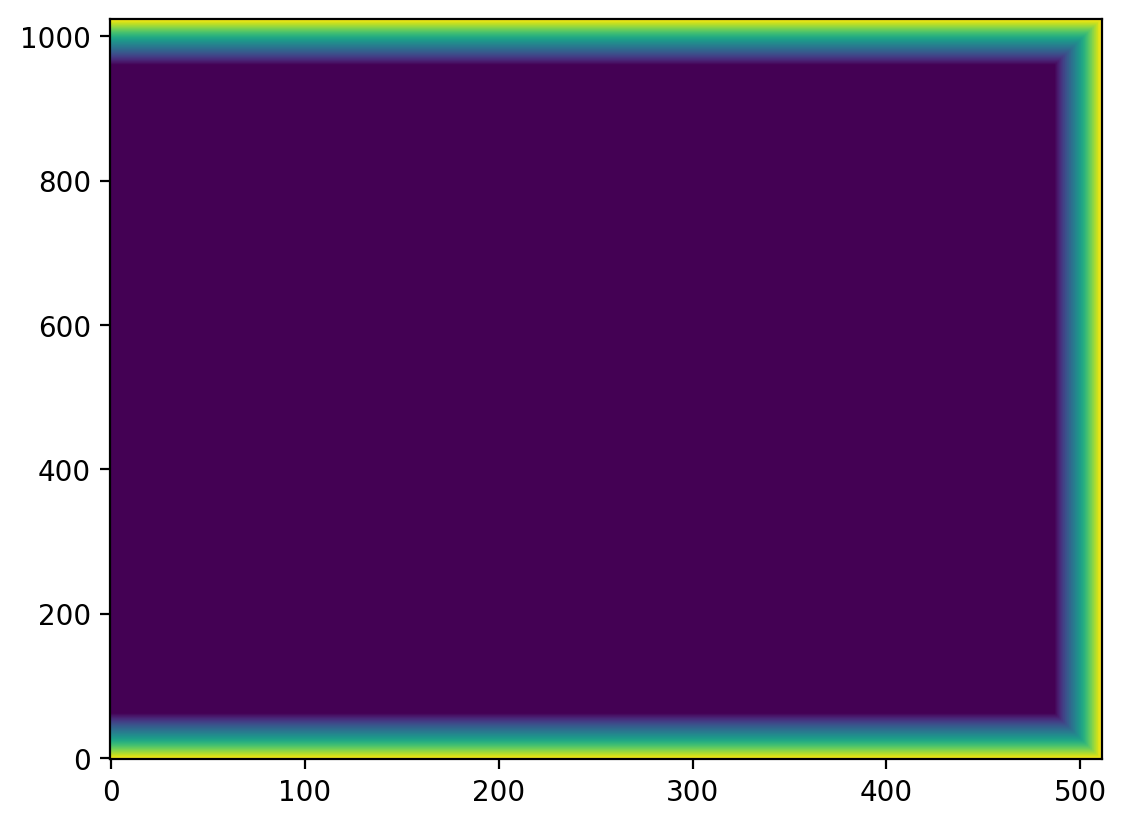

(512,)
Interpolation time: 0.08 seconds
Mask grid shape: (1536, 768)


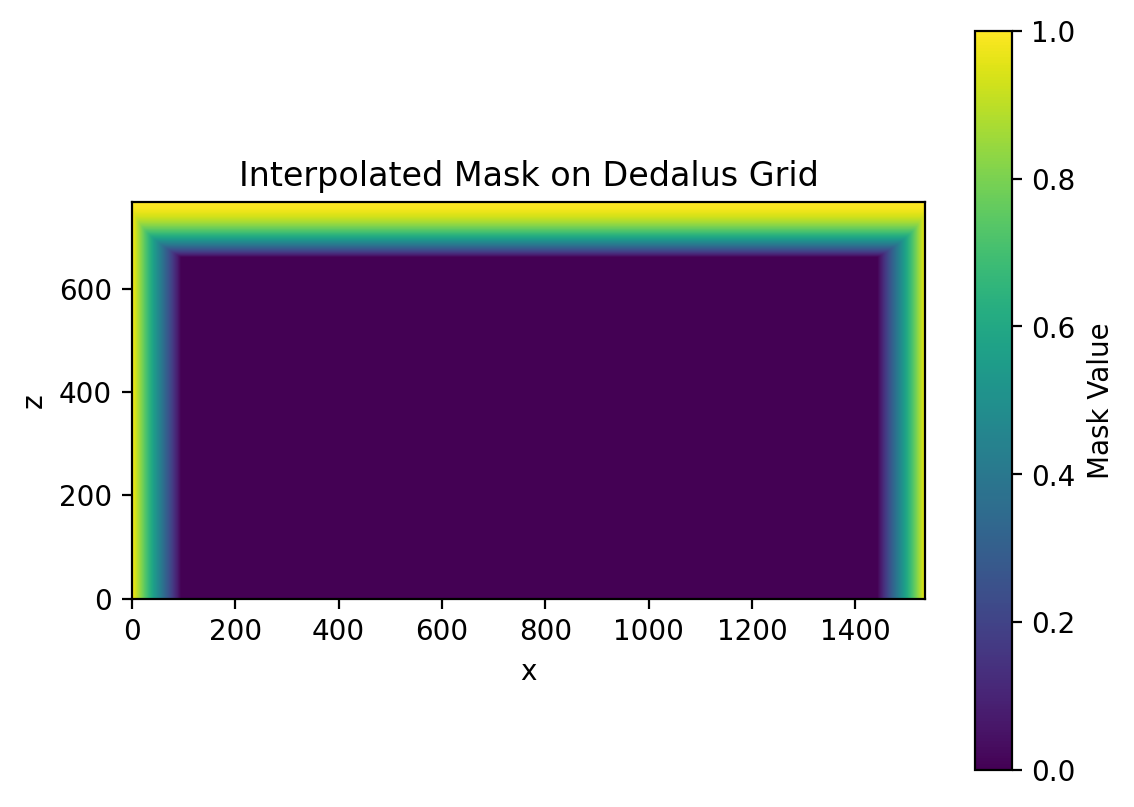

In [2]:
xl = np.linspace(0,Lx,Nx)
zl = np.linspace(0,Lz,Nz)

# def mountain_shape(x):
#     return np.where((x >= 0.4) & (x <= 0.6), 0.02 * np.sin(5*np.pi*(x-0.4)), 0)

def mountain_shape(x):
    return -2*(x-0.4)*(x-0.6)



print(xl.shape)
height = mountain_shape(xl)

newcell = np.zeros((Nx,Nz),dtype=int)

# #LR Sponge
# newcell[:Nx//10][:]=1
# newcell[Nx-Nx//10:][:]=1

# Initialize the grid

newcell = np.zeros((Nx, Nz))
temp = np.zeros((Nx, Nz))

# For the left side: linear increase from x=0 to x=Nx//20
x_left = np.linspace(1, 0, Nx//16)
newcell[:Nx//16, :] = x_left[:, np.newaxis]

# For the right side: linear increase from x=Nx-Nx//20 to x=Nx
x_right = np.linspace(0, 1, Nx//16)
newcell[Nx-Nx//16:, :] = x_right[:, np.newaxis]

# For the top: linear increase from z=Nz-Nz//20 to z=Nz
z_top = np.linspace(0, 1, Nz//20)
temp[:, Nz-Nz//20:] = z_top[np.newaxis, :]

newcell=np.maximum(newcell,temp)


# for i in range(Nx):
#     for j in range(Nz):
#         if height[i] > zl[j]:
#             newcell[j,i] = 0
#         else:
#             newcell[j,i] = 1
print(newcell.shape)

plt.imshow(newcell, origin='lower', aspect='auto')
plt.show()
# newcell = newcell-.5
# plt.imshow(newcell)
# newdistance = skfmm.distance(newcell, dx = 2**(1/2)*Lx/Nx ,periodic=(False,True))
# newdistance = skfmm.distance(newcell, dx = [Lz/Nz,Lx/Nx] ,periodic=(False,True))
# newdistance = newdistance-0.5

def mask(x): return 0.5*(1-erf(np.pi**(1/2)*x))

dtype = np.float64
dealias = 3/2

# Bases
coords = d3.CartesianCoordinates('x', 'z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)
x = dist.local_grid(xbasis)
x= x[:,0]
z = dist.local_grid(zbasis)
z = z[0,:]
print(z.shape)



dtype = np.float64
dealias = 3/2

# Bases
coords = d3.CartesianCoordinates('x', 'z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

def mask(x): return 0.5*(1-erf(np.pi**(1/2)*x))




# Create mask field
mask_grid = dist.Field(name='mask', bases=(xbasis, zbasis))

# Interpolate mask onto Dedalus grid
mask_grid.change_scales(dealias)
xg = dist.local_grid(xbasis, scale=dealias)
zg = dist.local_grid(zbasis, scale=dealias)
interp_smooth = sci.RegularGridInterpolator((xl, zl), newcell, 
                                            bounds_error=True, fill_value=1)
start_time = time.time()
# print("111",distance_func((zg[:,None],xg[None,:])).shape)
# Vectorized interpolation
X, Z = np.meshgrid(xg[:, 0], zg[0, :], indexing='ij')
mask_grid['g'] = interp_smooth((xg[None,:],zg[:,None]))
# mask_grid['g'] = interp_smooth((zg, xg))  
# mask_grid['g'] = mask(newdistance/δ)

end_time = time.time()

print(f"Interpolation time: {end_time - start_time:.2f} seconds")
print(f"Mask grid shape: {mask_grid['g'].shape}")

xplt,zplt=np.meshgrid(xg[:,0],zg[0,:])
plt.imshow(mask_grid['g'].T,origin='lower')
# plt.pcolormesh(xg,zg, mask_grid['g'].T, shading='nearest')
plt.colorbar(label='Mask Value')
plt.title('Interpolated Mask on Dedalus Grid')
plt.xlabel('x')
plt.ylabel('z')
plt.show()

# plt.plot(xg[:,0],mask_grid['g'][:,80])
# plt.ylim(0, 1)
# plt.show()


In [3]:
import h5py
    
with h5py.File('masks/mask_sp.h5', 'w') as f:
    f['mask'] = mask_grid['g']
    f['x'] = x
    f['z'] = z


In [6]:
# import h5py
    
# with h5py.File('masks/mask_sptop.h5', 'w') as f:
#     f['mask'] = mask_grid['g']
#     f['x'] = x
#     f['z'] = z
